# ENGR 1451/2451 — Weekly Assignment 5
**10 points**

Practice loading a CSV file, selecting complete observations, calculating correlations, making scatterplots and a correlation heat map, and writing a reusable function to compare individual and grouped data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

LE5-2 uses the supplied **`data/penguins.csv`** file. Keep the `data` folder beside this notebook. Use the folder containing the notebook as the working directory. The other exercises retain the embedded synthetic teaching data.

Select observations by conditions, not row positions. Calculate counts and cutoffs from the data. Label scatterplot axes with units. Keep written comments brief and tied to your calculated results.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from IPython.display import display

## LE5-1. Compare laptop measurements (3 pts)

Each row describes one laptop. `battery_Wh` is battery capacity in watt-hours, `mass_kg` is mass in kilograms, and `runtime_h` is measured battery runtime in hours. Two entries are missing.

### A. Select complete observations (1 pt)

Create `complete` by selecting the three columns in `feature_cols` and dropping rows missing **any** of them. Report the number of laptops retained and excluded, using counts calculated from the data.

In [4]:
battery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,
              72, 75, 78, 84, 90, 96, np.nan, 80]
laptops = pd.DataFrame({
    "battery_Wh": battery_Wh,
    "mass_kg": [1.2, 1.1, 1.6, 1.2, 1.5, 1.3, 1.4, 1.8,
                1.5, 1.6, 1.9, 2.0, 1.7, 2.1, 1.8, 2.0],
    "runtime_h": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,
                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],
})
laptop_labels = {
    "battery_Wh": "Battery capacity (Wh)",
    "mass_kg": "Mass (kg)",
    "runtime_h": "Battery runtime (h)",
}
feature_cols = list(laptop_labels)
laptop_settings = {
    "lower_quantile": 0.25,
    "upper_quantile": 0.75,
}

complete = laptops.dropna()

print("Retained:", len(complete))
print("Excluded:", len(laptops)-len(complete))

Retained: 14
Excluded: 2


### B. Plot a pair (1 pt)

Using `complete`, make a scatterplot of **battery capacity** on the x-axis and **runtime** on the y-axis. Calculate Pearson's $r$. Describe the direction and shape of the plotted association in one sentence.

**Answer:** The association is strongly positive (increasing together) and approximately linear.

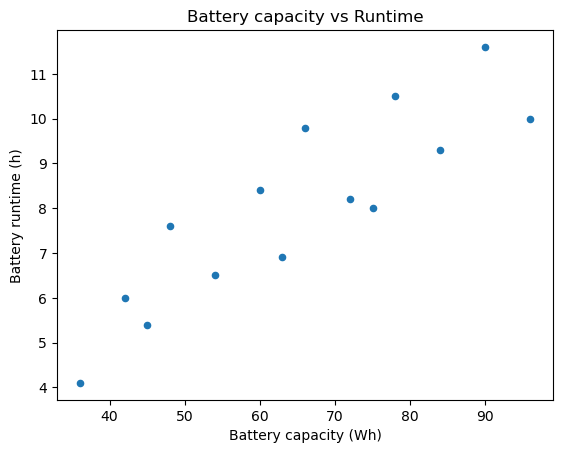

,Mean,s
battery_Wh,64.93,18.55
mass_kg,1.56,0.31
runtime_h,8.02,2.11


n = 14
Pearson r = 0.878


In [10]:
xcol = "battery_Wh"
ycol = "runtime_h"

ax = complete.plot.scatter(x=xcol, y=ycol)
ax.set(
    xlabel=laptop_labels[xcol],
    ylabel=laptop_labels[ycol],
    title="Battery capacity vs Runtime"
)
plt.show()

r = complete[xcol].corr(complete[ycol])

summary = pd.DataFrame({
    "Mean": complete.mean(),
    "s": complete.std(ddof=1)
})

display(summary.round(2))
print(f"n = {len(complete)}")
print(f"Pearson r = {r:.3f}")

### C. Restrict the range (1 pt)

Calculate the battery-capacity cutoffs at the quantiles specified in `laptop_settings`. Create `restricted` using `.loc[]` and `&` to keep capacities **between those cutoffs, including both endpoints**. Do not hard-code the cutoffs.

Display one table comparing the number of observations $n$ and the battery-capacity/runtime correlation $r$ for `complete` and `restricted`. Briefly report how $r$ changed.

**Answer:** r for the restricted dataset decreased by almost half compared to the complete dataset

In [34]:
low_cutoff = complete["battery_Wh"].quantile(laptop_settings["lower_quantile"])
high_cutoff = complete["battery_Wh"].quantile(laptop_settings["upper_quantile"])

restricted = complete.loc[(complete["battery_Wh"]>= low_cutoff) & (complete["battery_Wh"]<= high_cutoff)]

r_complete = complete[xcol].corr(complete[ycol])
r_restricted = restricted[xcol].corr(restricted[ycol])

summary = pd.DataFrame({
    "data frame":["complete","restricted"],
    "n": [len(complete), len(restricted)],
    "r": [r_complete, r_restricted],
})

print(summary)

   data frame   n         r
0    complete  14  0.878026
1  restricted   6  0.437600


## LE5-2. Cross-correlation matrix from a CSV file (3 pts)

Use the **Palmer Penguins** data in `data/penguins.csv`. Each row represents one penguin. Analyze the four physical measurements listed in `penguin_labels`; do not include species, island, sex, or year in the matrix.

Source: Horst, Hill, and Gorman, [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), with measurements collected by Kristen Gorman and Palmer Station LTER. [Variable definitions](https://allisonhorst.github.io/palmerpenguins/reference/penguins.html). The supplied CSV is the copy distributed with [plotnine](https://plotnine.org/reference/penguins.html); the data are licensed CC0. No additional package is needed to load the CSV.

### A. Load and prepare the data (1 pt)

Use `pd.read_csv()` to load `csv_path` into `penguins` and display its first few rows. Select `measurement_cols`, then drop rows missing **any of these four measurements**, storing the result as `penguin_complete`. Do not drop observations just because sex or another unused column is missing.

Report the number of rows loaded, retained, and excluded. Use the same `penguin_complete` observations throughout this exercise.

In [41]:
csv_path = Path("data/penguins.csv")
penguin_labels = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}
measurement_cols = list(penguin_labels)

penguins = pd.read_csv(csv_path)
penguins.head()

penguin_complete = penguins.dropna(subset=penguin_labels)
penguin_complete.head()

print("Loaded:", len(penguins))
print("Retained:", len(penguin_complete))
print("Excluded:", len(penguins)-len(penguin_complete))

Loaded: 344
Retained: 342
Excluded: 2


### B. Calculate and display the matrix (1 pt)

Calculate the **Pearson cross-correlation matrix** for all four columns of `penguin_complete` and name it `corr_matrix`. Here, the matrix contains the pairwise correlations between the measurement columns, not correlations at time lags. Display it rounded to three decimal places, keeping the unrounded matrix for plotting and subsequent calculations.

**The heat-map code is provided below; do not rewrite it.** Run the function-definition cell, then use `ax = plot_correlation_heatmap(corr_matrix)` after calculating your matrix. The fixed scale maps **−1 to dark red, 0 to white, and +1 to dark blue**.

In [46]:
# Provided plotting code: run this cell unchanged.
def plot_correlation_heatmap(corr_matrix):
    """Plot the student's matrix on a fixed red–white–blue scale."""
    cmap = LinearSegmentedColormap.from_list(
        "correlation_rwb", ["darkred", "white", "darkblue"], N=257
    )  # An odd palette size makes the middle color exactly white.

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(
        corr_matrix, cmap=cmap, vmin=-1, vmax=1, interpolation="nearest"
    )
    positions = np.arange(len(corr_matrix.columns))
    labels = [penguin_labels[column] for column in corr_matrix.columns]
    ax.set_xticks(positions, labels=labels, rotation=45, ha="right")
    ax.set_yticks(positions, labels=labels)
    ax.set_title("Palmer Penguins: Pearson correlation matrix", pad=14)

    for (row, col), value in np.ndenumerate(corr_matrix.to_numpy()):
        ax.text(
            col, row, f"{value:.2f}", ha="center", va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

    fig.colorbar(image, ax=ax, label="Pearson r", ticks=[-1, -0.5, 0, 0.5, 1])
    fig.tight_layout()
    plt.show()
    return ax

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


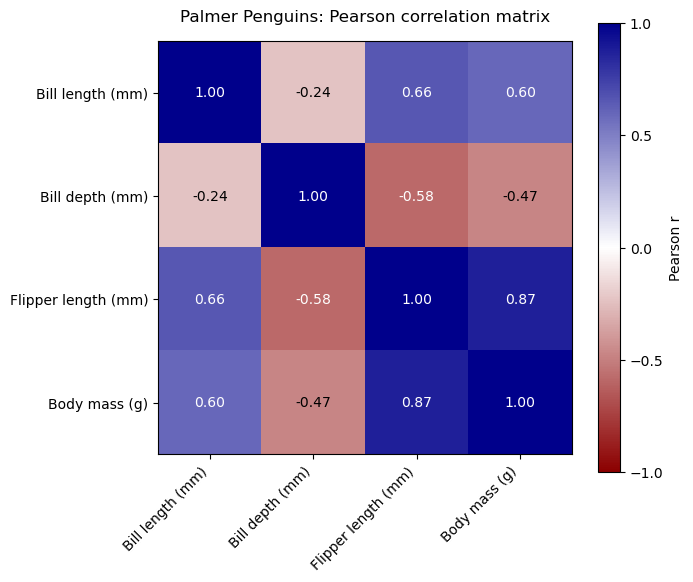

In [51]:
# Your corr_matrix calculation and rounded display here

corr_matrix = penguin_complete[measurement_cols].corr(method="pearson")
display(corr_matrix.round(3))

# After calculating corr_matrix, uncomment the following line:
ax = plot_correlation_heatmap(corr_matrix)

### C. Select pairs and make a scatterplot (1 pt)

Use your matrix to identify the **strongest positive** and **strongest negative** correlations between distinct measurements. Ignore the diagonal and count each pair only once. Report both pairs and retrieve their correlations with `.loc[]`, rather than typing the correlation values by hand.

Make a scatterplot for whichever of these two pairs has the larger absolute correlation. Label the axes using `penguin_labels` and include its $r$ in the title.

Strongest positive correlation: body mass and flipper length with r= 0.8712017673060111
Strongest negative correlation: flipper length and bill depth with r= -0.5838512164654143


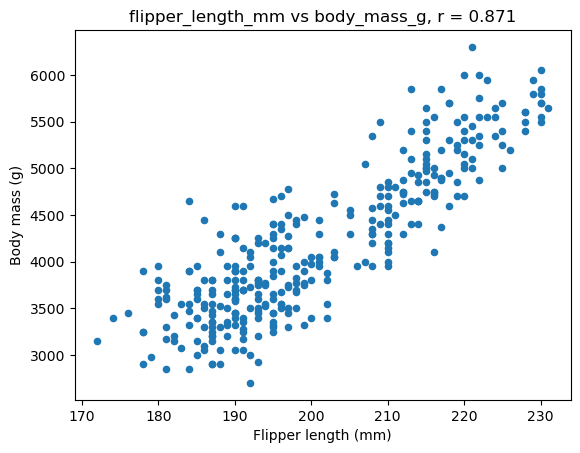

In [61]:
# Identify the two pairs and retrieve their r values from corr_matrix.
print("Strongest positive correlation: body mass and flipper length with r=", corr_matrix.loc["flipper_length_mm","body_mass_g"])
print("Strongest negative correlation: flipper length and bill depth with r=", corr_matrix.loc["flipper_length_mm","bill_depth_mm"])

# Plot the pair with the larger absolute correlation.
xcol = "flipper_length_mm"
ycol = "body_mass_g"
r_value = corr_matrix.loc["flipper_length_mm","body_mass_g"]
tit = f"{xcol} vs {ycol}, r = {r_value:.3f}"

ax = penguin_complete.plot.scatter(x=xcol, y=ycol)
ax.set(
    xlabel=penguin_labels[xcol],
    ylabel=penguin_labels[ycol],
    title=tit
)

plt.show()

## LE5-3. Compare a curved pattern with an added observation (2 pts)

A process-development team records product yield at several temperatures. Each row is one run. `yield_pct` is the percentage of starting material recovered as the desired product.

### A. Plot the original runs (1 pt)

Plot temperature on the x-axis and yield on the y-axis, then calculate Pearson's $r$. Use a condition on `yield_pct` to display the run or runs with the highest observed yield. Briefly describe the plotted pattern.

**Answer:** The plotted pattern is a negative parabola.

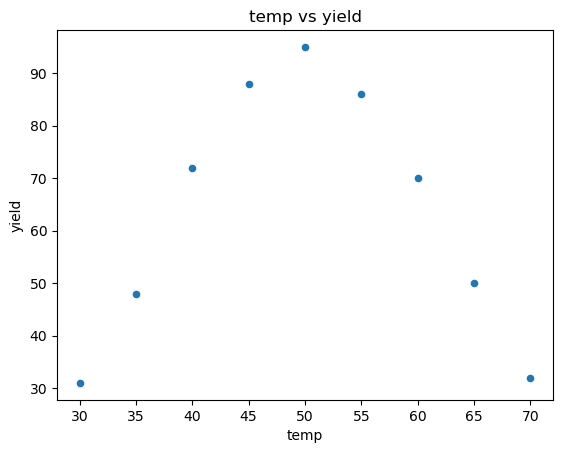

Pearson's r = 0.0075451107882686915
The temperaturea and yield of the highest yield run temperature_C    50
yield_pct        95
Name: 4, dtype: int64


In [65]:
runs = pd.DataFrame({
    "temperature_C": [30, 35, 40, 45, 50, 55, 60, 65, 70],
    "yield_pct": [31, 48, 72, 88, 95, 86, 70, 50, 32],
})

# Your scatterplot, Pearson correlation, and maximum-yield run selection here
ax = runs.plot.scatter(x="temperature_C", y="yield_pct")
ax.set(
    xlabel="temp",
    ylabel="yield",
    title="temp vs yield"
)

plt.show()

r_yield = runs["temperature_C"].corr(runs["yield_pct"])
print("Pearson's r =", r_yield)

highest_yield = runs.loc[runs["yield_pct"].idxmax()]
print("The temperaturea and yield of the highest yield run:", highest_yield)

### B. Add one unusual observation (1 pt)

Use `pd.concat()` to combine `runs` and `extra_run` into a new DataFrame, `all_runs`; retain the original data.

Display one table comparing $n$ and $r$ for the original and combined data. Make a scatterplot of the combined data, marking the additional run with a different marker and adding a legend. Report the numerical change in $r$ (combined minus original).

  data frame   n         r
0   original   9  0.007545
1   all runs  10 -0.558668


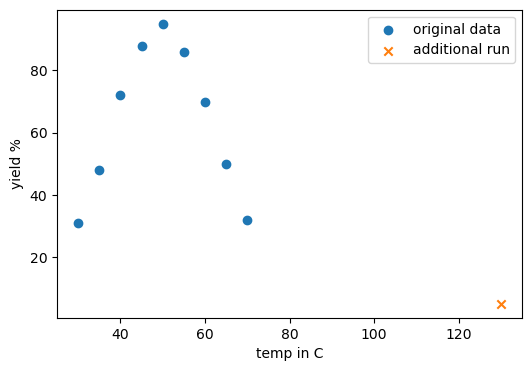

Change in r: -0.5662131995813564


In [74]:
extra_run = pd.DataFrame({"temperature_C": [130], "yield_pct": [5]})

# Your combined data, n/r comparison, and scatterplot here
all_runs = pd.concat([runs, extra_run])

r_yield_og = runs["temperature_C"].corr(runs["yield_pct"])
r_yield_new = all_runs["temperature_C"].corr(all_runs["yield_pct"])
compare = pd.DataFrame({
    "data frame":["original","all runs"],
    "n": [len(runs), len(all_runs)],
    "r": [r_yield_og, r_yield_new],
})
print(compare)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(runs["temperature_C"], runs["yield_pct"], marker="o", label="original data")
ax.scatter(extra_run["temperature_C"], extra_run["yield_pct"], marker="x", label="additional run")
ax.set_xlabel("temp in C")
ax.set_ylabel("yield %")
ax.legend()
plt.show()

change_in_r = r_yield_new - r_yield_og
print("Change in r:", change_in_r)

## LE5-4. Write a function and use it twice (2 pts)

Each row below is one trainee in one of four workshops. The records give practice hours and an assembly assessment score on a 0–100 scale. These are synthetic observational records.

### A. Write and call your function (1 pt)

The individual and workshop-average analyses require the same scatterplot, count, and correlation. Write **`plot_and_summarize(data, title)`** to do that work once in a reusable function.

Your function must:

1. Create and display a **new scatterplot** of `practice_hours` on the x-axis and `assembly_score` on the y-axis. Label the axes **Practice hours (h)** and **Assembly score (0–100)**, and use the supplied `title`.
2. Calculate the number of rows $n$ and Pearson's $r$ from the supplied `data`.
3. **Return a `pd.Series`** with entries named `"n"` and `"r"`, rather than only printing them.

Use the `data` argument for every calculation and plot; do not refer to `trainees` or `workshop_means` inside the function. Do not hard-code the row count or correlation.

**First call:** Call your function on `trainees` with the title `"Individual trainees"`. Store its returned Series as `individual_summary` and display it. Write both the function body and the call yourself.

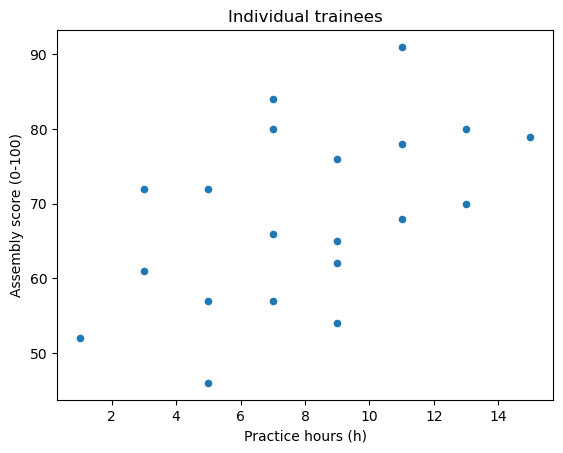

n    20.000000
r     0.516575
dtype: float64

In [82]:
trainees = pd.DataFrame({
    "workshop": ["A"] * 5 + ["B"] * 5 + ["C"] * 5 + ["D"] * 5,
    "practice_hours": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,
                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],
    "assembly_score": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,
                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],
})

def plot_and_summarize(data, title):
    """Plot practice hours versus score and return a Series containing n and r."""
    # Write your function body here.
    ax = data.plot.scatter(x="practice_hours", y="assembly_score")
    ax.set(
        xlabel="Practice hours (h)",
        ylabel="Assembly score (0-100)",
        title=title
    )
    plt.show()
    
    n = len(data)
    r = data["practice_hours"].corr(data["assembly_score"])
    
    return pd.Series({"n": n, "r": r})

individual_summary = plot_and_summarize(trainees, "Individual trainees")
 
display(individual_summary)


### B. Reuse the function for workshop averages (1 pt)

Use `.groupby(...).agg(...)` to create `workshop_means`, with one row per workshop showing its trainee count, mean practice hours, and mean assembly score. Name the count column `trainee_count`, and keep the two mean columns named **`practice_hours`** and **`assembly_score`** so the same function can analyze them. Display this table.

**Second call:** Call the **same function** on `workshop_means` with the title `"Workshop averages"`. Store its returned Series as `workshop_summary`. The returned $n$ now counts workshop rows, not individual trainees.

Use `individual_summary` and `workshop_summary` to create one labeled comparison table containing $n$ and $r$. Do not duplicate the scatterplot or correlation code outside the function. Briefly report how $r$ changed after aggregation.

**Answer:** R is much stronger after aggregation. There is a stronger positive correlation between assembly scores and practice hours when accounting for the specific workshops.

,trainee_count,practice_hours,assembly_score
workshop,,,
A,5,5.0,54.0
B,5,7.0,65.0
C,5,9.0,73.0
D,5,11.0,82.0


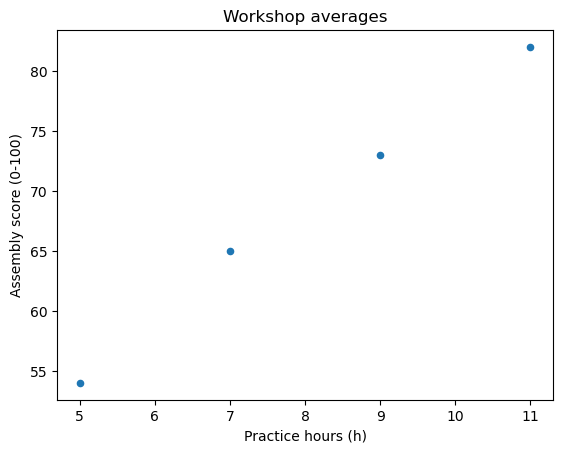

   grouped by     n         r
0  individual  20.0  0.516575
1    workshop   4.0  0.997880


In [98]:
# Create and display workshop_means using .groupby(...).agg(...).
workshop_means = trainees.groupby("workshop").agg(
    trainee_count=("practice_hours", "count"),
    practice_hours=("practice_hours", "mean"),
    assembly_score=("assembly_score","mean")
)
display(workshop_means)

workshop_summary = plot_and_summarize(workshop_means, "Workshop averages")

summary_all = pd.DataFrame({
    "grouped by":["individual","workshop"],
    "n": [individual_summary.iloc[0], workshop_summary.iloc[0]],
    "r": [individual_summary.iloc[1], workshop_summary.iloc[1]],
})

print(summary_all)

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 1,
  "session_date": "2026-10-06",
  "messages": [
    {"i": 1, "who": "student", "text": "I'm a little confused what LE5-1C is asking for. It says to calculate the battery capacity cutoffs at the quantiles specified (0.25 and 0.75). Am I supposed to use cdf?"},
    {"i": 2, "who": "tutor", "text": "No, you don't need a CDF here, though your instinct is close. The two ideas are inverses of each other.\n\nA CDF takes a value and gives you the fraction of the data at or below it: \"30 Wh is at the 20th percentile.\" A quantile goes the other way. You give it a fraction, and it returns the value that has that fraction of the data at or below it: \"the 0.25 quantile is the capacity that 25% of laptops fall at or below.\" Since `laptop_settings` gives you the fractions (0.25 and 0.75) and you want the capacities, you want quantiles.\n\nIn pandas that is one method on a column:\n\n```python\n# toy example, unrelated data\nscores = pd.Series([2, 4, 6, 8, 10, 12, 14, 16])\nlo = scores.quantile(0.25)   # value with 25% of the data at or below it\nhi = scores.quantile(0.75)\n```\n\nThe level goes in as a fraction between 0 and 1, so `.quantile(0.25)`, not `.quantile(25)`. When the level doesn't land exactly on an observation, pandas interpolates linearly between neighbors, so a cutoff can be a number that isn't in your data. That is expected.\n\nSo the step is really three moves:\n\n1. Compute the two cutoffs from the battery-capacity column, reading the levels out of `laptop_settings` rather than typing them.\n2. Use `.loc[]` with two conditions joined by `&` to keep the rows between those cutoffs, including both endpoints. That means asking which comparison operators include the boundary value.\n3. Build one table with n and r for `complete` and for `restricted`, then write a brief report of how r changed.\n\nWhich column and which frame do you think the quantiles should come from? And is there an operator choice that's giving you trouble in step 2? Either way, you've already got the main idea: the cutoffs are values computed from the data."},
    {"i": 3, "who": "student", "text": "okay this is what I wrote \"low_cutoff = complete.quantile(laptop_settings[\"lower_quantile\"])\nhigh_cutoff = complete.quantile(laptop_settings[\"upper_quantile\"])\n\nrestricted = complete.loc[(complete[\"battery_Wh\"]>= low_cutoff) & (complete[\"battery_Wh\"]<= high_cutoff)]\" but im getting an error \"Can only compare identically-labeled Series objects\"", "code": true},
    {"i": 4, "who": "tutor", "text": "The error comes from the two `quantile` lines, not the filter. `complete.quantile(0.25)` runs on the whole DataFrame, so it returns one cutoff per column: a Series of three values labeled `battery_Wh`, `mass_kg`, and `runtime_h`. Then `complete[\"battery_Wh\"] >= low_cutoff` compares a Series labeled by row numbers against a Series labeled by column names. pandas refuses because the labels don't match.\n\nYou want a single number for battery capacity, so call `.quantile()` on just that column. Generic shape, on a toy frame:\n\n```python\ntoy = pd.DataFrame({\"a\": [1, 2, 3, 4], \"b\": [10, 20, 30, 40]})\ntoy.quantile(0.5)        # Series with one value per column\ntoy[\"a\"].quantile(0.5)   # a single number\n```\n\nOnce `low_cutoff` and `high_cutoff` are single numbers, your `.loc[]` line should work as written. Your frame (`complete`), the `laptop_settings` keys, and the `>=` and `<=` operators already match what the prompt asks for.\n\nTry changing those two lines and let me know if anything else comes up."},
    {"i": 5, "who": "student", "text": "why does this code \"xcol = \"flipper_length_mm\"\nycol = \"body_mass_g\"\n\nax = penguin_complete.plot.scatter(x=xcol, y=ycol)\nax.set(\n    xlabel=penguin_labels[xcol],\n    ylabel=penguin_labels[ycol],\n    title=penguin_labels[xcol], \"vs\", penguin_labels[ycol], \"r=\" corr_matrix.loc[\"flipper_length_mm\",\"body_mass_g\"]\n)\n\nplt.show()\" give me the error positional argument follows keyword argument?", "code": true},
    {"i": 6, "who": "tutor", "text": "Python is reading your `title=` line as several separate arguments. Inside a call like `ax.set(...)`, commas separate arguments, and `title=` accepts exactly one value. Here is how it gets parsed:\n\n- `title=penguin_labels[xcol]` is the first argument, and it is a keyword argument (it has a name).\n- The comma after it starts a new argument, `\"vs\"`. This one has no name, so it is positional.\n- Python requires positional arguments to come before keyword arguments, so it stops with \"positional argument follows keyword argument.\"\n\nThere is a second problem right behind it. `\"r=\" corr_matrix.loc[...]` has no operator or comma between the string and the value, so Python would raise a syntax error there next.\n\nThe fix is to build the title as one string before it reaches `title=`. An f-string is the usual way, because it lets you drop values into the text with `{}`:\n\n```python\n# toy example, unrelated data\nname_a = \"Height (cm)\"\nname_b = \"Weight (kg)\"\nvalue = 0.87654\n\ntext = f\"{name_a} vs {name_b}, r = {value:.3f}\"\nprint(text)   # Height (cm) vs Weight (kg), r = 0.877\n\nax.set(title=text)   # or put the f-string directly after title=\n```\n\nAnything inside `{}` is evaluated as ordinary Python, so `{penguin_labels[xcol]}` and `{corr_matrix.loc[\"flipper_length_mm\", \"body_mass_g\"]:.3f}` both work. If you put the `.loc[]` call inside an f-string that is itself delimited with double quotes, use single quotes for the labels inside it, or the quotes will clash. The `:.3f` part rounds the displayed value to three decimals without changing the number itself.\n\nThe rest of your code (the `xcol`/`ycol` variables, the axis labels from `penguin_labels`, and retrieving r with `.loc[]` instead of typing it) matches what the prompt asks for. Once the title is a single string, give it another run and let me know what you get."},
    {"i": 7, "who": "student", "text": "how do I change the marker on a scatter plot for a specific data point and add a label? for LE5-3B"},
    {"i": 8, "who": "tutor", "text": "You do it with two separate scatter calls on the same axes, each with its own `marker` and `label`, then one `ax.legend()`. Matplotlib builds the legend from whatever has a `label=`, so the single special point is just a second call that happens to contain one row.\n\n```python\n# toy example, unrelated data\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\nmain = pd.DataFrame({\"dose_mg\": [1, 2, 3, 4], \"response\": [2.0, 3.9, 6.1, 8.0]})\nodd = pd.DataFrame({\"dose_mg\": [12], \"response\": [1.5]})\n\nfig, ax = plt.subplots(figsize=(6, 4))\nax.scatter(main[\"dose_mg\"], main[\"response\"], marker=\"o\", label=\"Typical\")\nax.scatter(odd[\"dose_mg\"], odd[\"response\"], marker=\"x\", s=80, color=\"red\", label=\"Unusual\")\nax.set_xlabel(\"Dose (mg)\")\nax.set_ylabel(\"Response (units)\")\nax.legend()\nplt.show()\n```\n\n- `marker=` sets the shape: `\"o\"` circle, `\"x\"` cross, `\"s\"` square, `\"^\"` triangle, `\"D\"` diamond.\n- `s=` sets the size and `color=` the color. Giving the special point a larger size or a different color makes it easier to spot.\n- Both calls draw on the same `ax`, so they share one set of axes.\n- If you forget `label=`, `ax.legend()` has nothing to show and matplotlib warns that no labeled artists were found.\n- Set the axis labels and call `ax.legend()` before `plt.show()`, or they won't appear.\n\nThe idea is to split the points into groups, one scatter call per group. In the toy example the groups already live in separate frames. If they were stacked in one frame, you could split them with a Boolean mask on a column, such as `df.loc[df[\"flag\"] == \"special\"]`, which selects by condition rather than by row position. You can decide which approach fits LE5-3B, since the prompt rules out picking the point by position.\n\nThe `.loc[]` and `pd.concat` pieces you've been using on the earlier problems carry over here. Want me to go over how to build the n and r comparison table, or is the plotting the only snag?"},
    {"i": 9, "who": "student", "text": "so I plot both runs and extra_run just with different markers? I can't just plot all_runs and then use .loc to specify a data point I want to have a different marker?"},
    {"i": 10, "who": "tutor", "text": "Yes, you can do it either way. Both are valid, and neither selects by row position.\n\n**Option 1: plot the two frames you already have.** `runs` holds the original points and `extra_run` holds the added one, so two `ax.scatter` calls with different `marker` and `label` values cover everything. The combined frame is still what you use for the n and r table.\n\n**Option 2: plot the combined frame, then overlay the special point.** This works, but there are two catches:\n\n- If you scatter all of `all_runs` first, the special point is drawn with the regular marker too, and your overlay sits on top of it. You may see a circle hiding under your x.\n- If you give the first call a label like \"original runs,\" the legend describes the extra point incorrectly, since that call included it.\n\nTo avoid both, split the combined frame into two groups with a Boolean mask and plot each group once. The mask needs a condition that identifies the extra point without a row number. A common way is to test membership against another object:\n\n```python\n# toy example, unrelated data\nbase = pd.DataFrame({\"k\": [1, 2, 3]})\nextra = pd.DataFrame({\"k\": [99]})\nboth = pd.concat([base, extra], ignore_index=True)\n\nis_extra = both[\"k\"].isin(extra[\"k\"])   # True where the value appears in extra\nboth.loc[is_extra]      # just the special rows\nboth.loc[~is_extra]     # everything else\n```\n\n`.isin()` returns True for each row whose value appears in the other collection, and `~` flips True and False. Whether a membership test on one column is reliable enough depends on your data, so think about whether any original value could match.\n\nOption 1 is the simpler of the two and fully meets the prompt. Which one fits how you've built `all_runs`?"},
    {"i": 11, "who": "student", "text": "this is the code I wrote for LE5-4A. \"trainees = pd.DataFrame({\n    \"workshop\": [\"A\"] * 5 + [\"B\"] * 5 + [\"C\"] * 5 + [\"D\"] * 5,\n    \"practice_hours\": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,\n                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],\n    \"assembly_score\": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,\n                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],\n})\n\ndef plot_and_summarize(data, title):\n    \"\"\"Plot practice hours versus score and return a Series containing n and r.\"\"\"\n    # Write your function body here.\n    ax = data.plot.scatter(x=\"practice_hours\", y=\"assembly_score\")\n    ax.set(\n        xlabel=\"Practice hours (h)\",\n        ylabel=\"Assembly score (0-100)\",\n        title=title\n    )\n    plt.show()\n    \n    n = len(data)\n    r = data[\"practice_hours\"].corr(data[\"assembly_score\"])\n    sumnr = pd.Series({\"n\": n, \"r\": r})\n    \n    return ax, sumnr\n\ncall = plot_and_summarize(trainees, \"Individual Trainees\")\nindividual_summary = \n\n\" the only part im stuck on is how do I store the returned series as individual summary and display it?", "code": true},
    {"i": 12, "who": "tutor", "text": "Storing and displaying are two small moves, and your question points at a real problem in the function, so I'll cover that first.\n\n**Your function returns two things, not one.** `return ax, sumnr` packs both into a tuple. The prompt says the function must return a `pd.Series` with entries `\"n\"` and `\"r\"`, so `individual_summary` should end up being the Series itself. If you assign the call's result as it stands, `individual_summary` would be a tuple `(ax, Series)`, and `display()` would show that tuple rather than a clean Series. It would also cause trouble in LE5-4B when you build the comparison table from the two returned Series. Everything above the `return` already matches what you need, so the only change is what comes back.\n\n**How storing works.** A function call is an expression whose value is whatever the function returns. Putting a name and `=` in front of the call stores that value:\n\n```python\n# toy example, unrelated data\ndef describe(values, label):\n    total = sum(values)\n    return pd.Series({\"label_length\": len(label), \"total\": total})\n\nresult = describe([3, 4, 5], \"demo\")   # result now holds the returned Series\n```\n\nYour line `individual_summary = ` is missing its right-hand side, which is why it's incomplete. The call goes there, in place of your `call = ...` line. You also don't need the separate `call` variable.\n\n**How displaying works.** Either of these shows the stored value:\n\n- `display(result)`, which works anywhere in a cell.\n- Writing `result` alone as the last line of the cell. Only the last bare expression in a cell displays automatically.\n\nAlso, the Series holds a count and a correlation together, so n will display with a decimal point (like `20.0`). That is expected and not an error.\n\nYour function body already uses `data` for everything, creates a fresh figure through `data.plot.scatter`, and calculates n and r instead of typing them, which is the hard part of this step. Make the change to the return, store the call as `individual_summary`, display it, and let me know what you get."},
    {"i": 13, "who": "student", "text": "oh okay so like this \"trainees = pd.DataFrame({\n    \"workshop\": [\"A\"] * 5 + [\"B\"] * 5 + [\"C\"] * 5 + [\"D\"] * 5,\n    \"practice_hours\": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,\n                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],\n    \"assembly_score\": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,\n                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],\n})\n\ndef plot_and_summarize(data, title):\n    \"\"\"Plot practice hours versus score and return a Series containing n and r.\"\"\"\n    # Write your function body here.\n    ax = data.plot.scatter(x=\"practice_hours\", y=\"assembly_score\")\n    ax.set(\n        xlabel=\"Practice hours (h)\",\n        ylabel=\"Assembly score (0-100)\",\n        title=title\n    )\n    plt.show()\n    \n    n = len(data)\n    r = data[\"practice_hours\"].corr(data[\"assembly_score\"])\n    \n    return pd.Series({\"n\": n, \"r\": r})\n\nindividual_summary = plot_and_summarize(trainees, \"Individual Trainees\")\n \nprint(individual_summary)\"", "code": true},
    {"i": 14, "who": "tutor", "text": "That's the structure the step needs. The function now returns a single `pd.Series` named by its `\"n\"` and `\"r\"` entries, and `individual_summary` holds it. Everything inside the function still reads from `data`, so the second call on `workshop_means` will work too.\n\nTwo small things to check against the prompt:\n\n- **The title text.** The prompt says to call the function with the title `\"Individual trainees\"`, with a lowercase \"t\" in \"trainees\". Yours has a capital T. It's a one-character edit in the call.\n- **Display versus print.** The prompt asks you to display the Series. `print(individual_summary)` shows the values as plain text, while `display(individual_summary)` (already imported in your setup cell) renders it the way pandas shows a Series elsewhere in your notebook. Either shows the numbers, but `display()` is what the prompt names.\n\nIf you edit the function cell later, remember to re-run it before the call, since the call uses whichever version was last run.\n\nYou wrote the whole function body and the call yourself, including the fix to the return. When you're ready for LE5-4B, say so, or ask me anything about `.groupby(...).agg(...)` first."}
  ],
  "events": [
    {"i": 1, "part": "5-1C", "type": "explain"},
    {"i": 3, "part": "5-1C", "type": "code"},
    {"i": 5, "part": "5-2C", "type": "code"},
    {"i": 7, "part": "5-3B", "type": "explain"},
    {"i": 9, "part": "5-3B", "type": "explain"},
    {"i": 11, "part": "5-4A", "type": "code"},
    {"i": 13, "part": "5-4A", "type": "code"}
  ],
  "parts": [
    {"part": "5-1C", "exchanges": 2, "max_tier": 3, "passed": false},
    {"part": "5-2C", "exchanges": 1, "max_tier": 3, "passed": false},
    {"part": "5-3B", "exchanges": 2, "max_tier": 1, "passed": false},
    {"part": "5-4A", "exchanges": 2, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "No step involved a long stall; each snag cleared within one or two exchanges. The sticking points were calling .quantile() on the whole DataFrame instead of the battery_Wh column (5-1C), building a single title string instead of several comma-separated arguments (5-2C), separating one point so it gets its own marker and legend entry (5-3B), and returning a tuple instead of one Series and then storing and displaying it (5-4A). None of the four steps was confirmed finished in this session, so passed is false for each.",
    "No unstuck declarations and no release-valve use occurred, so nothing looked like a failure of the tutoring. Most questions were concept or syntax questions answered directly, and the student wrote all code and prose themselves."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.